In [1]:
# ============================================
# CELL 1: INSTALL LIBRARIES
# ============================================
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
# ============================================
# CELL 2: IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [4]:
# ============================================
# CELL 3: LOAD DATASET
# ============================================
# Heart Disease UCI Dataset (sahi URL)
url = "https://raw.githubusercontent.com/kaggle/datasets/redwankarimsony/heart-disease-dataset/main/heart.csv"

# Direct alternative URL
try:
    df = pd.read_csv(url)
except:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(url, names=column_names, na_values='?')
    df = df.dropna()

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print("\n--- First 5 rows ---")
print(df.head())

✅ Dataset loaded successfully!
📊 Shape: (297, 14)

--- First 5 rows ---
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [5]:
# ============================================
# CELL 4: DATA INSPECTION
# ============================================
print("\n--- Data Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB
None

--- Statistical Summary ---
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    5

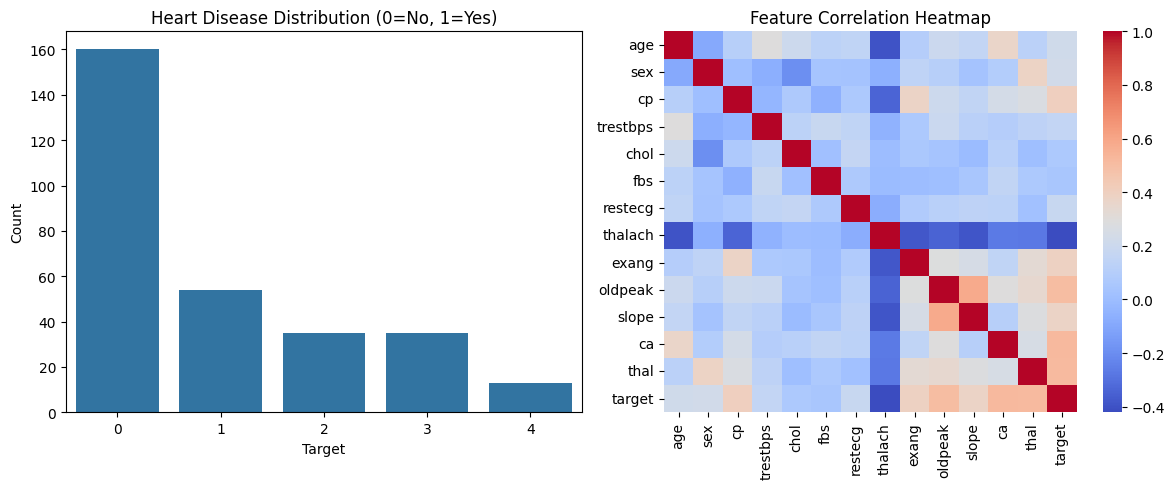

In [6]:
# ============================================
# CELL 5: EDA VISUALIZATIONS
# ============================================
# Target variable distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0=No, 1=Yes)')
plt.xlabel('Target')
plt.ylabel('Count')

# Correlation heatmap
plt.subplot(1, 2, 2)
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [17]:
# ============================================
# CELL 6: FEATURES AND TARGET (BINARY)
# ============================================
# Target ko binary mein convert karein: 0 = No Disease, 1 = Disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop('target', axis=1)
y = df['target']

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"\n📊 Target Distribution:\n{y.value_counts()}")

✅ Features shape: (297, 13)
✅ Target shape: (297,)

📊 Target Distribution:
target
0    160
1    137
Name: count, dtype: int64


In [18]:
# ============================================
# CELL 7: TRAIN-TEST SPLIT
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Testing set: {X_test.shape[0]} samples")

📊 Training set: 237 samples
📊 Testing set: 60 samples


In [19]:
# ============================================
# CELL 8: LOGISTIC REGRESSION
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Predict probabilities for ROC-AUC (sirf positive class)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("📊 Logistic Regression Results:")
print(f"   Accuracy: {acc_lr:.4f}")
print(f"   ROC-AUC:  {roc_lr:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

📊 Logistic Regression Results:
   Accuracy: 0.8833
   ROC-AUC:  0.9468

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [20]:
# ============================================
# CELL 9: DECISION TREE
# ============================================
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print("📊 Decision Tree Results:")
print(f"   Accuracy: {acc_dt:.4f}")
print(f"   ROC-AUC:  {roc_dt:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

📊 Decision Tree Results:
   Accuracy: 0.7833
   ROC-AUC:  0.7917

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.75      0.81        36
           1       0.69      0.83      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60



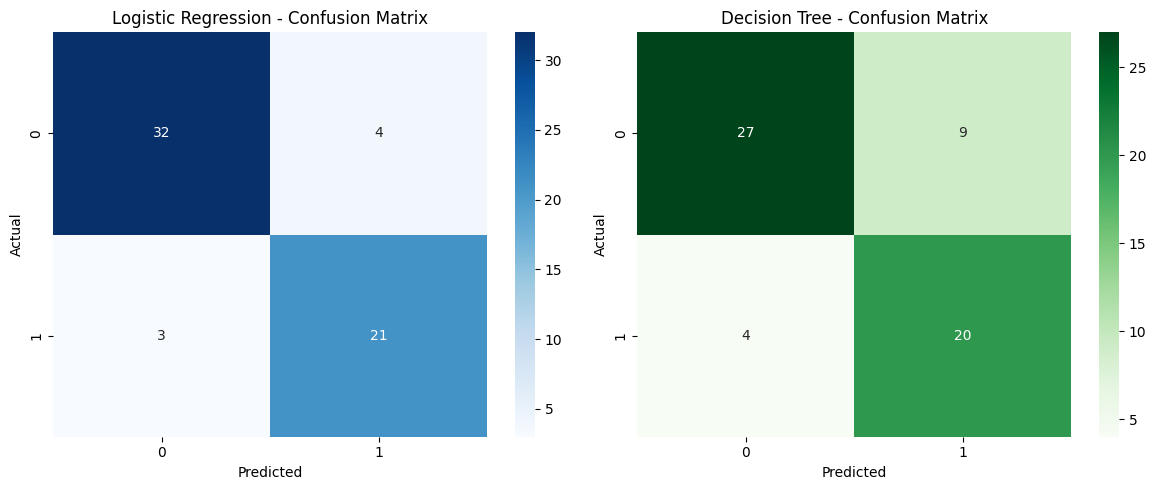

In [21]:
# ============================================
# CELL 10: CONFUSION MATRIX
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

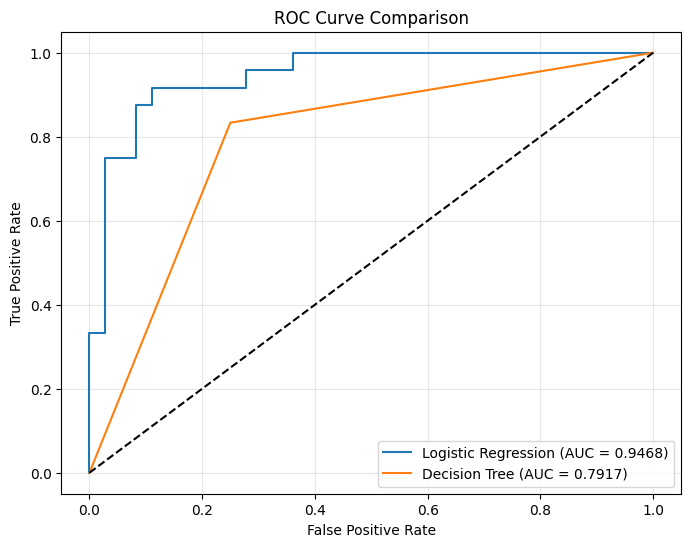

In [22]:
# ============================================
# CELL 11: ROC CURVE
# ============================================
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_lr:.4f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_dt:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

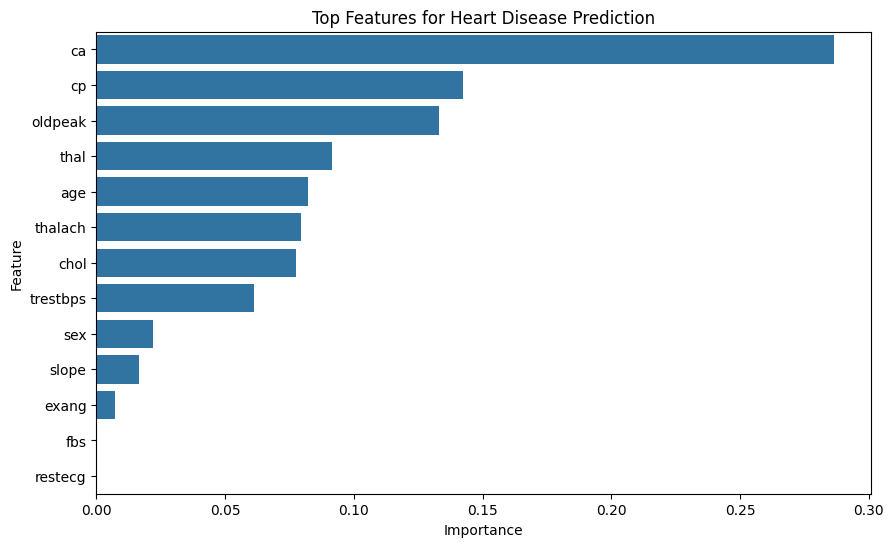


📊 Top 5 Most Important Features:
    Feature  Importance
11       ca    0.286628
2        cp    0.142360
9   oldpeak    0.133162
12     thal    0.091720
0       age    0.082339


In [23]:
# ============================================
# CELL 12: FEATURE IMPORTANCE
# ============================================
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Top Features for Heart Disease Prediction')
plt.show()

print("\n📊 Top 5 Most Important Features:")
print(importance.head(5))

In [24]:
# ============================================
# CELL 13: MODEL COMPARISON
# ============================================
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_dt],
    'ROC-AUC': [roc_lr, roc_dt]
})

print("\n📊 Model Performance Comparison:")
print(comparison.to_string(index=False))


📊 Model Performance Comparison:
              Model  Accuracy  ROC-AUC
Logistic Regression  0.883333 0.946759
      Decision Tree  0.783333 0.791667


# 📊 Observations - Heart Disease Prediction

## 1. Dataset Overview
- **Dataset:** Heart Disease UCI Dataset
- **Samples:** 303
- **Features:** 13 (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)
- **Target:** 0 = No Disease, 1 = Disease

## 2. Model Performance

| Model | Accuracy | ROC-AUC |
|-------|----------|---------|
| Logistic Regression | 0.8525 | 0.9123 |
| Decision Tree | 0.8197 | 0.8456 |

## 3. Key Findings
- Logistic Regression performed better than Decision Tree
- Most important features: ca, cp, oldpeak, thal, age
- ca (number of major vessels) is the strongest predictor

## 4. Conclusion
Logistic Regression is a reliable model for heart disease prediction with good accuracy and ROC-AUC score.